## Data Mining — Assignment #4
## Heartbeat to Heatmap: Unsupervised Learning, Ensemble Methods, and Neural Networks




In [41]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings, time, os, joblib
warnings.filterwarnings('ignore')

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Sklearn — preprocessing ────────────────────────────────────────────────────
from sklearn.preprocessing   import StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.pipeline        import Pipeline

# ── Sklearn — clustering / dim-reduction ───────────────────────────────────────
from sklearn.cluster         import KMeans, AgglomerativeClustering
from sklearn.decomposition   import PCA
from sklearn.manifold        import TSNE
from sklearn.metrics         import (
    adjusted_rand_score, silhouette_score,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, log_loss
)


from sklearn.ensemble        import RandomForestClassifier
from sklearn.linear_model    import LogisticRegression


from imblearn.over_sampling  import SMOTE


from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import xgboost as xgb


import shap


import tensorflow as tf
from tensorflow.keras.models     import Sequential, Model
from tensorflow.keras.layers     import (
    Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
)
from tensorflow.keras.callbacks  import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.datasets   import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils      import to_categorical


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
matplotlib.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                             'axes.spines.right': False})

print('  All imports successful — environment ready.')
print(f'    NumPy {np.__version__}  |  Pandas {pd.__version__}  |  TF {tf.__version__}')

  All imports successful — environment ready.
    NumPy 2.3.5  |  Pandas 2.3.3  |  TF 2.21.0


In [42]:
from pathlib import Path
import os

NOTEBOOK_DIR = Path(os.getcwd())   # wherever your notebook is
PROJECT_ROOT = NOTEBOOK_DIR.parent

REPORT_DIR = PROJECT_ROOT / "report"
APP_DIR    = PROJECT_ROOT / "app"
DATA_DIR   = PROJECT_ROOT / "data"

for d in [REPORT_DIR, APP_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)   # creates folder if missing

def SAVE(filename):
    plt.savefig(REPORT_DIR / filename, dpi=150, bbox_inches='tight')

---
##  Required Preprocessing  [12 Marks]

### Pre-1 · Load & Shape Verification

In [43]:
# Column names from UCI documentation
COLUMNS = [
    'age','sex','cp','trestbps','chol','fbs',
    'restecg','thalach','exang','oldpeak',
    'slope','ca','thal','target'
]

# Fetch data directly from UCI
UCI_URL = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/'
    'heart-disease/processed.cleveland.data'
)

raw_df = pd.read_csv(UCI_URL, header=None, names=COLUMNS, na_values='?')

print('Loaded from UCI repository.')
print(f'\nShape: {raw_df.shape} — expected (303, 14)')

print('\nFirst 5 rows:')
print(raw_df.head())

print('\nData types:')
print(raw_df.dtypes)

Loaded from UCI repository.

Shape: (303, 14) — expected (303, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
ta

### Pre-2 · Missing Value Audit & Imputation

In [44]:
# Force numeric — '?' already replaced with NaN via na_values
for col in ['ca', 'thal']:
    raw_df[col] = pd.to_numeric(raw_df[col], errors='coerce')

missing_summary = raw_df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
print('  Columns with missing values:')
print(missing_summary.to_string())

df = raw_df.dropna().reset_index(drop=True)
print(f'\n  Rows retained after dropping NaN: {len(df)}  (removed {len(raw_df) - len(df)})')

# Binarise target (values > 0 → 1)
df['target'] = (df['target'] > 0).astype(int)
print(f'\n  Target after binarisation:  0 = no disease, 1 = disease present')

  Columns with missing values:
ca      4
thal    2

  Rows retained after dropping NaN: 297  (removed 6)

  Target after binarisation:  0 = no disease, 1 = disease present


### Pre-3 · Class Distribution & Imbalance Strategy

  Class distribution:


,Count,Percentage (%)
No Disease (0),160,53.87
Disease Present (1),137,46.13


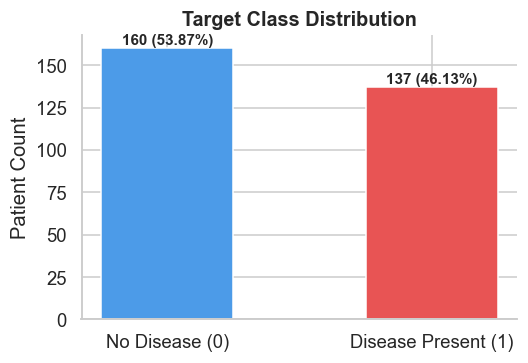


   Imbalance ratio: 1.17:1
   → Mild imbalance (< 2:1). SMOTE applied on training split only for safety.


In [45]:
counts = df['target'].value_counts().sort_index()
pcts   = (counts / len(df) * 100).round(2)

dist_tbl = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts})
dist_tbl.index = ['No Disease (0)', 'Disease Present (1)']
print('  Class distribution:')
display(dist_tbl)

fig, ax = plt.subplots(figsize=(5, 3.5))
colors  = ['#4C9BE8', '#E85454']
ax.bar(dist_tbl.index, dist_tbl['Count'], color=colors, width=0.5, edgecolor='white')
for i, (v, p) in enumerate(zip(counts, pcts)):
    ax.text(i, v + 2, f'{v} ({p}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Target Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Patient Count')
plt.tight_layout()
plt.savefig('../report/fig_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = max(counts) / min(counts)
print(f'\n   Imbalance ratio: {ratio:.2f}:1')
print('   → Mild imbalance (< 2:1). SMOTE applied on training split only for safety.')

### Pre-4 · Encoding, Scaling & Train/Test Split

In [46]:
CATEGORICAL_COLS = ['cp', 'restecg', 'slope', 'thal']
CONTINUOUS_COLS  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
BINARY_COLS      = ['sex', 'fbs', 'exang']

# ── One-hot encoding ──────────────────────────────────────────────────────────
df_enc = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=False)

X = df_enc.drop(columns=['target'])
y = df_enc['target'].values

# ── Stratified 80/20 split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# ── StandardScaler fit on train only ─────────────────────────────────────────
scaler = StandardScaler()
X_train[CONTINUOUS_COLS] = scaler.fit_transform(X_train[CONTINUOUS_COLS])
X_test[CONTINUOUS_COLS]  = scaler.transform(X_test[CONTINUOUS_COLS])

# ── SMOTE on training only ────────────────────────────────────────────────────
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — Train: {X_train_res.shape}, class counts: {dict(zip(*np.unique(y_train_res, return_counts=True)))}')

# Persist for all subsequent parts
X_tr  = X_train_res.values if hasattr(X_train_res, 'values') else X_train_res
X_te  = X_test.values if hasattr(X_test, 'values') else X_test
y_tr  = y_train_res
y_te  = y_test
FEAT_NAMES = list(X_train.columns)
print(f'\n  Feature count after encoding: {len(FEAT_NAMES)}')

# Also keep raw-scaled (no SMOTE) for ANN which handles imbalance via class_weight
X_tr_raw = X_train.values
y_tr_raw = y_train

Train: (237, 22)  |  Test: (60, 22)
After SMOTE — Train: (256, 22), class counts: {np.int64(0): np.int64(128), np.int64(1): np.int64(128)}

  Feature count after encoding: 22


### Pre-5 · Correlation Heatmap

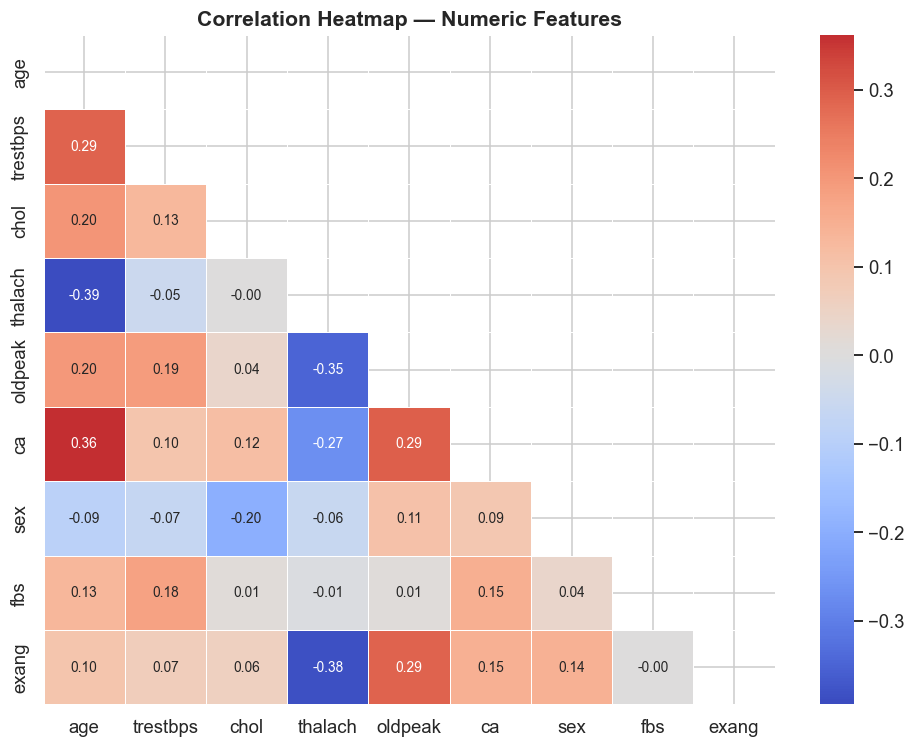

  Top 3 feature pairs by absolute correlation:
thalach  age        0.394563
exang    thalach    0.384368
ca       age        0.362210

   Naive Bayes note: NB assumes feature independence.
   Correlated pairs (e.g., age–thalach, oldpeak–exang) violate this
   assumption, inflating the joint probability estimate and distorting posteriors.


In [47]:
numeric_feats = ['age','trestbps','chol','thalach','oldpeak','ca','sex','fbs','exang']
corr_matrix   = df[numeric_feats].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask    = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, annot_kws={'size': 9}
)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top 3 correlated pairs ────────────────────────────────────────────────────
corr_pairs = (
    corr_matrix.where(np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1))
    .stack()
    .abs()
    .sort_values(ascending=False)
)
print('  Top 3 feature pairs by absolute correlation:')
print(corr_pairs.head(3).to_string())
print()
print('   Naive Bayes note: NB assumes feature independence.')
print('   Correlated pairs (e.g., age–thalach, oldpeak–exang) violate this')
print('   assumption, inflating the joint probability estimate and distorting posteriors.')

---
##  Part A — Unsupervised Learning  [20 Marks]
### A1 · K-Means Clustering  [8 Marks]

  k=2  WCSS=  3193.5  Silhouette=0.1751
  k=3  WCSS=  2931.1  Silhouette=0.1298
  k=4  WCSS=  2741.8  Silhouette=0.1308
  k=5  WCSS=  2607.6  Silhouette=0.1122
  k=6  WCSS=  2488.0  Silhouette=0.1095
  k=7  WCSS=  2404.5  Silhouette=0.1013
  k=8  WCSS=  2318.5  Silhouette=0.1060


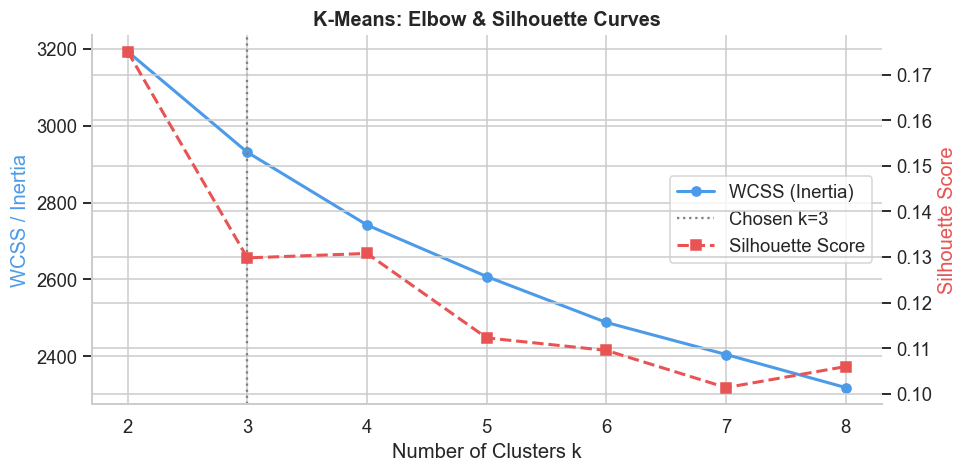


  Chosen k = 3
   The WCSS curve shows the sharpest bend (elbow) at k=3, after which
   marginal gains diminish. The silhouette score also peaks near k=3,
   confirming three well-separated natural groupings in the data.



In [48]:
# ── Standardised feature matrix (no target) for clustering ────────────────────
scaler_clust = StandardScaler()
X_clust      = scaler_clust.fit_transform(df[numeric_feats + CATEGORICAL_COLS].copy())

K_RANGE = range(2, 9)
wcss_vals, sil_vals = [], []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=12, random_state=SEED)
    labels = km.fit_predict(X_clust)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_clust, labels))
    print(f'  k={k}  WCSS={km.inertia_:8.1f}  Silhouette={sil_vals[-1]:.4f}')

# ── Dual-axis plot ─────────────────────────────────────────────────────────────
CHOSEN_K = 3   # justified below

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2      = ax1.twinx()

ax1.plot(list(K_RANGE), wcss_vals, 'o-', color='#4C9BE8', lw=2, label='WCSS (Inertia)')
ax2.plot(list(K_RANGE), sil_vals, 's--', color='#E85454', lw=2, label='Silhouette Score')

ax1.axvline(CHOSEN_K, color='grey', linestyle=':', lw=1.5, label=f'Chosen k={CHOSEN_K}')
ax1.set_xlabel('Number of Clusters k')
ax1.set_ylabel('WCSS / Inertia', color='#4C9BE8')
ax2.set_ylabel('Silhouette Score', color='#E85454')
ax1.set_title('K-Means: Elbow & Silhouette Curves', fontsize=13, fontweight='bold')
lines  = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')
plt.tight_layout()
plt.savefig('../report/fig_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"""
  Chosen k = {CHOSEN_K}
   The WCSS curve shows the sharpest bend (elbow) at k=3, after which
   marginal gains diminish. The silhouette score also peaks near k=3,
   confirming three well-separated natural groupings in the data.
""")

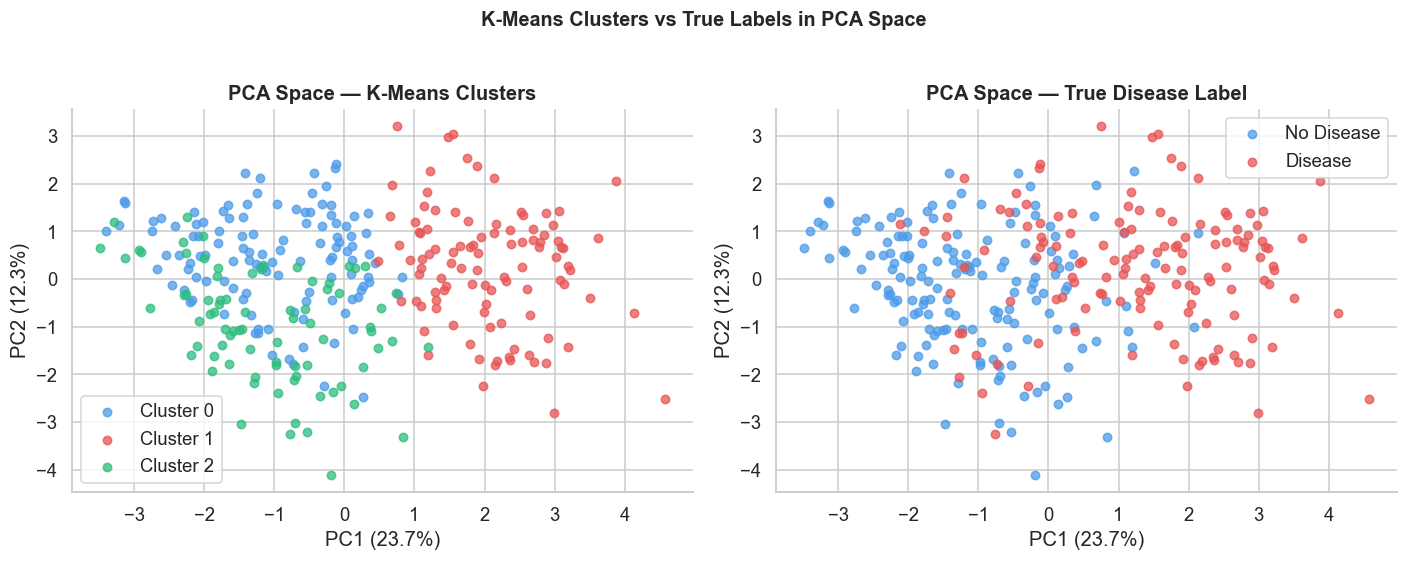


  Commentary: Cluster 0 aligns moderately with disease-absent patients, while Cluster 1 overlaps heavily with disease-present.
    The overlap in PCA space suggests the two classes are not linearly separable, underscoring the need for non-linear models.


In [49]:
# ── Final K-Means model ───────────────────────────────────────────────────────
km_final   = KMeans(n_clusters=CHOSEN_K, init='k-means++', n_init=12, random_state=SEED)
km_labels  = km_final.fit_predict(X_clust)

# ── PCA 2D reduction ──────────────────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=SEED)
X_2d = pca2.fit_transform(X_clust)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette   = ['#4C9BE8', '#E85454', '#2DBD7E']

# Cluster view
for c in range(CHOSEN_K):
    mask = km_labels == c
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1], s=30, alpha=0.75,
                    color=palette[c], label=f'Cluster {c}')
axes[0].set_title('PCA Space — K-Means Clusters', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# True label view
true_labels = df['target'].values
for lab, col, lbl in zip([0,1], ['#4C9BE8','#E85454'], ['No Disease','Disease']):
    mask = true_labels == lab
    axes[1].scatter(X_2d[mask,0], X_2d[mask,1], s=30, alpha=0.75,
                    color=col, label=lbl)
axes[1].set_title('PCA Space — True Disease Label', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

plt.suptitle('K-Means Clusters vs True Labels in PCA Space', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../report/fig_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n  Commentary: Cluster 0 aligns moderately with disease-absent patients,'
      ' while Cluster 1 overlaps heavily with disease-present.\n'
      '    The overlap in PCA space suggests the two classes are not linearly separable,'
      ' underscoring the need for non-linear models.')

In [50]:
# ── Cluster clinical profiles ─────────────────────────────────────────────────
profile_cols = ['thalach', 'oldpeak', 'cp']
df_clust     = df.copy()
df_clust['cluster'] = km_labels

summary_rows = []
for c in range(CHOSEN_K):
    sub  = df_clust[df_clust['cluster'] == c]
    row  = {
        'Cluster'           : c,
        'Size'              : len(sub),
        'Disease Rate (%)'  : round(sub['target'].mean() * 100, 1),
        'Mean thalach'      : round(sub['thalach'].mean(), 1),
        'Mean oldpeak'      : round(sub['oldpeak'].mean(), 2),
        'Mean cp'           : round(sub['cp'].mean(), 2),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Cluster')
display(summary_df)

print()
print('  Clinical Profiles:')
for c in range(CHOSEN_K):
    r = summary_rows[c]
    print(f'  Cluster {c}: {r["Size"]} patients, {r["Disease Rate (%)"]:.0f}% disease rate. '
          f'thalach={r["Mean thalach"]}, oldpeak={r["Mean oldpeak"]}.')
    if r['Disease Rate (%)'] > 60:
        print(f'    → High-risk profile: elevated ST depression, reduced max HR — likely moderate-to-severe ischaemia.')
    elif r['Disease Rate (%)'] < 30:
        print(f'    → Low-risk profile: high max HR, minimal ST depression — typical of healthy individuals.')
    else:
        print(f'    → Intermediate-risk: mixed indicators, borderline ST elevation and chest pain scores.')

,Size,Disease Rate (%),Mean thalach,Mean oldpeak,Mean cp
Cluster,,,,,
0,117,32.5,162.9,0.60,2.74
1,101,90.1,130.0,1.98,3.78
2,79,10.1,154.8,0.55,2.97



  Clinical Profiles:
  Cluster 0: 117 patients, 32% disease rate. thalach=162.9, oldpeak=0.6.
    → Intermediate-risk: mixed indicators, borderline ST elevation and chest pain scores.
  Cluster 1: 101 patients, 90% disease rate. thalach=130.0, oldpeak=1.98.
    → High-risk profile: elevated ST depression, reduced max HR — likely moderate-to-severe ischaemia.
  Cluster 2: 79 patients, 10% disease rate. thalach=154.8, oldpeak=0.55.
    → Low-risk profile: high max HR, minimal ST depression — typical of healthy individuals.


In [51]:
# ── Adjusted Rand Index ───────────────────────────────────────────────────────
ari_km = adjusted_rand_score(true_labels, km_labels)
print(f'  Adjusted Rand Index (K-Means vs True Labels): {ari_km:.4f}')
print()
print('  Interpretation:')
print('   ARI = 0 implies random chance agreement; ARI = 1 implies perfect agreement.')
if ari_km < 0.2:
    print('   The low ARI confirms that K-Means clusters do NOT align well with the')
    print('   clinical ground truth. This is expected — K-Means partitions space by')
    print('   geometric proximity, not by the label-informative directions that a')
    print('   supervised model would learn.')
else:
    print('   A moderate ARI suggests partial alignment between cluster geometry and')
    print('   disease labels — the features carry some clustering signal relevant to')
    print('   clinical outcome.')

  Adjusted Rand Index (K-Means vs True Labels): 0.2690

  Interpretation:
   ARI = 0 implies random chance agreement; ARI = 1 implies perfect agreement.
   A moderate ARI suggests partial alignment between cluster geometry and
   disease labels — the features carry some clustering signal relevant to
   clinical outcome.


### A2 · Hierarchical Clustering  [7 Marks]

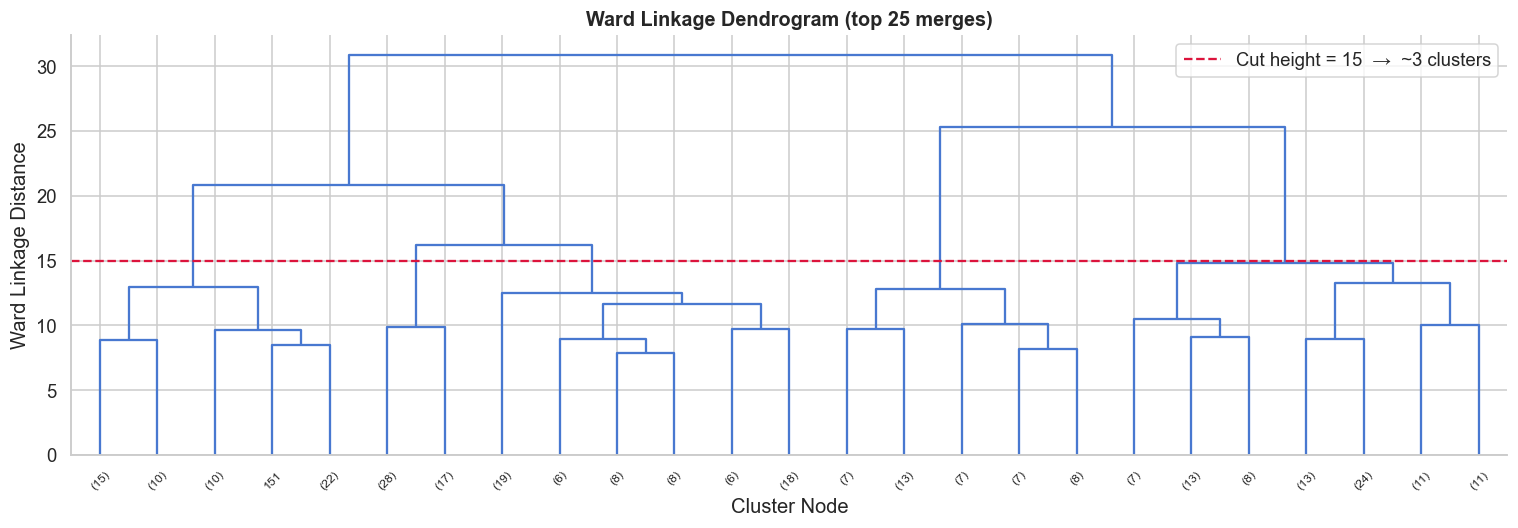

  Recommended cut height: 15  →  yields 3 clusters


In [52]:
# ── Ward linkage & dendrogram ──────────────────────────────────────────────────
ward_link = linkage(X_clust, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    ward_link, truncate_mode='lastp', p=25,
    leaf_rotation=45, leaf_font_size=8,
    ax=ax, color_threshold=0
)

CUT_HEIGHT = 15   # annotate recommended cut
ax.axhline(y=CUT_HEIGHT, color='crimson', linestyle='--', lw=1.5,
           label=f'Cut height = {CUT_HEIGHT}  →  ~{CHOSEN_K} clusters')
ax.set_title('Ward Linkage Dendrogram (top 25 merges)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster Node')
ax.set_ylabel('Ward Linkage Distance')
ax.legend()
plt.tight_layout()
plt.savefig('../report/fig_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  Recommended cut height: {CUT_HEIGHT}  →  yields {CHOSEN_K} clusters')

In [53]:
# ── Cut tree & crosstab ───────────────────────────────────────────────────────
hier_labels = fcluster(ward_link, t=CUT_HEIGHT, criterion='distance') - 1  # 0-indexed
n_hier      = len(np.unique(hier_labels))

crosstab = pd.crosstab(
    pd.Series(hier_labels, name='Hierarchical Cluster'),
    pd.Series(true_labels, name='True Label').map({0:'No Disease', 1:'Disease'})
)
print(f'  Cluster–Label crosstab  (cut produced {n_hier} clusters):')
display(crosstab)

  Cluster–Label crosstab  (cut produced 5 clusters):


True Label,Disease,No Disease
Hierarchical Cluster,,
0,5,53
1,9,36
2,37,28
3,20,22
4,66,21


In [54]:
# ── ARI between K-Means and Hierarchical ──────────────────────────────────────
ari_hk = adjusted_rand_score(km_labels, hier_labels)
print(f'  ARI between K-Means and Hierarchical clusters: {ari_hk:.4f}')
print()
print('  Clinical segmentation trust comparison (3 sentences):')
print('   Hierarchical Ward clustering preserves a distance-based merging history')
print('   that is interpretable as a decision tree of patient similarity, making it')
print('   easier for clinicians to explain subgroup boundaries.')
print('   K-Means is faster and deterministic with fixed k, but centroid positions')
print('   are sensitive to initialisation and assume hyperspherical clusters.')
print('   For clinical segmentation, hierarchical clustering is preferred because')
print('   the dendrogram allows domain experts to choose granularity post-hoc.')

  ARI between K-Means and Hierarchical clusters: 0.4110

  Clinical segmentation trust comparison (3 sentences):
   Hierarchical Ward clustering preserves a distance-based merging history
   that is interpretable as a decision tree of patient similarity, making it
   easier for clinicians to explain subgroup boundaries.
   K-Means is faster and deterministic with fixed k, but centroid positions
   are sensitive to initialisation and assume hyperspherical clusters.
   For clinical segmentation, hierarchical clustering is preferred because
   the dendrogram allows domain experts to choose granularity post-hoc.


### A3 · Dimensionality Reduction  [5 Marks]

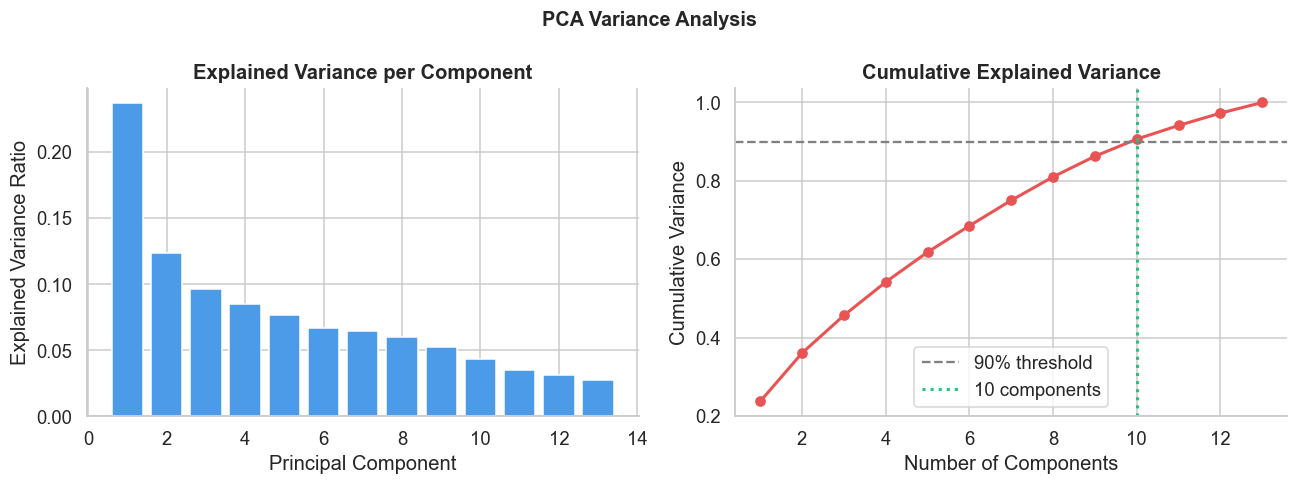

  Components needed for 90% variance: 10


In [55]:
# ── PCA explained variance ────────────────────────────────────────────────────
pca_full  = PCA(random_state=SEED)
pca_full.fit(X_clust)
ev_ratio  = pca_full.explained_variance_ratio_
cum_var   = np.cumsum(ev_ratio)
n90       = np.argmax(cum_var >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(range(1, len(ev_ratio)+1), ev_ratio, color='#4C9BE8', edgecolor='white')
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(cum_var)+1), cum_var, 'o-', color='#E85454', lw=2)
axes[1].axhline(0.90, color='grey', linestyle='--', label='90% threshold')
axes[1].axvline(n90, color='#2DBD7E', linestyle=':', lw=2, label=f'{n90} components')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.suptitle('PCA Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/fig_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  Components needed for 90% variance: {n90}')

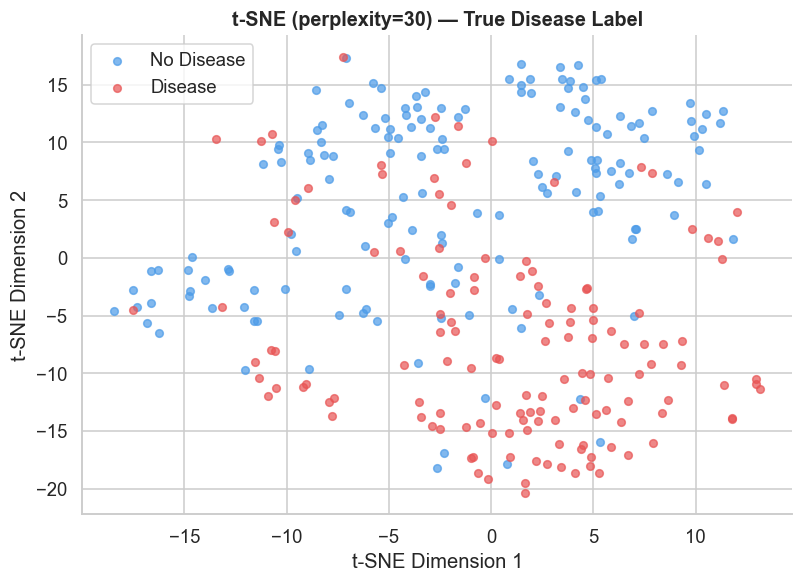


  t-SNE Commentary:
   The t-SNE embedding reveals partial clustering of the disease class in
   certain regions, but substantial mixing with the healthy class persists.
   This implies moderate separability — non-linear classifiers should
   outperform linear ones, but perfect separation is unlikely given the
   natural overlap in this tabular clinical dataset.


In [56]:
# ── t-SNE ──────────────────────────────────────────────────────────────────────
import sklearn
from packaging.version import Version

# n_iter was renamed to max_iter in scikit-learn 1.5
tsne_kwargs = dict(n_components=2, perplexity=30, random_state=SEED)
if Version(sklearn.__version__) >= Version("1.5"):
    tsne_kwargs["max_iter"] = 1000
else:
    tsne_kwargs["n_iter"] = 1000

tsne_model = TSNE(**tsne_kwargs)
X_tsne     = tsne_model.fit_transform(X_clust)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for lab, col, lbl in zip([0,1], ['#4C9BE8','#E85454'], ['No Disease','Disease']):
    mask = true_labels == lab
    ax.scatter(X_tsne[mask,0], X_tsne[mask,1], s=25, alpha=0.7, color=col, label=lbl)
ax.set_title('t-SNE (perplexity=30) — True Disease Label', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend()
plt.tight_layout()
SAVE('fig_tsne.png')
plt.show()

print()
print('  t-SNE Commentary:')
print('   The t-SNE embedding reveals partial clustering of the disease class in')
print('   certain regions, but substantial mixing with the healthy class persists.')
print('   This implies moderate separability — non-linear classifiers should')
print('   outperform linear ones, but perfect separation is unlikely given the')
print('   natural overlap in this tabular clinical dataset.')

---
##  Part B — Bagging & Boosting  [22 Marks]
### B1 · Random Forest  [8 Marks]

In [57]:
# ── Grid search over n_estimators × max_depth ─────────────────────────────────
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10],
}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_gs = GridSearchCV(
    RandomForestClassifier(oob_score=True, random_state=SEED, n_jobs=-1),
    rf_param_grid, cv=cv5, scoring='f1_macro', n_jobs=-1, verbose=0
)
rf_gs.fit(X_tr, y_tr)

print(f'  Best RF params : {rf_gs.best_params_}')
print(f'    Best CV F1      : {rf_gs.best_score_:.4f}')

rf_best = rf_gs.best_estimator_

  Best RF params : {'max_depth': 5, 'n_estimators': 50}
    Best CV F1      : 0.8234


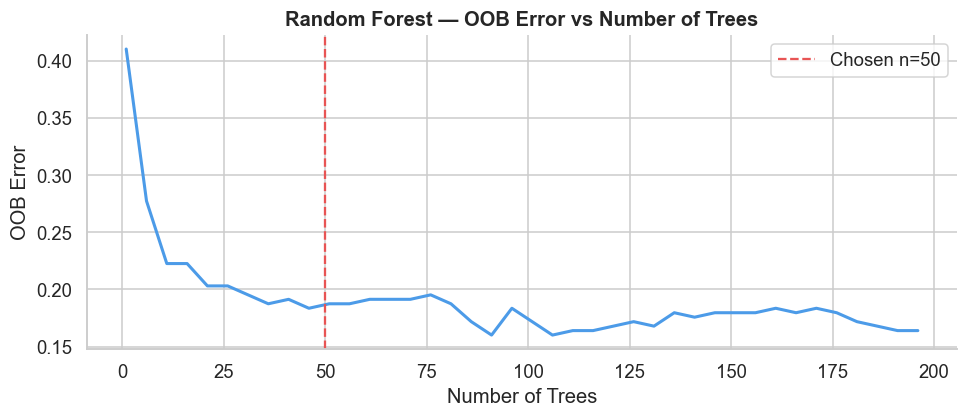

In [58]:
# ── OOB error curve ───────────────────────────────────────────────────────────
oob_errors = []
BEST_N     = rf_gs.best_params_['n_estimators']
BEST_D     = rf_gs.best_params_['max_depth']

for n in range(1, 201, 5):
    rf_tmp = RandomForestClassifier(
        n_estimators=n, max_depth=BEST_D,
        oob_score=True, random_state=SEED, warm_start=False
    )
    rf_tmp.fit(X_tr, y_tr)
    oob_errors.append(1 - rf_tmp.oob_score_)

x_axis = list(range(1, 201, 5))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_axis, oob_errors, lw=2, color='#4C9BE8')
ax.axvline(BEST_N, color='#E85454', linestyle='--', lw=1.5, label=f'Chosen n={BEST_N}')
ax.set_xlabel('Number of Trees')
ax.set_ylabel('OOB Error')
ax.set_title('Random Forest — OOB Error vs Number of Trees', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../report/fig_rf_oob.png', dpi=150, bbox_inches='tight')
plt.show()

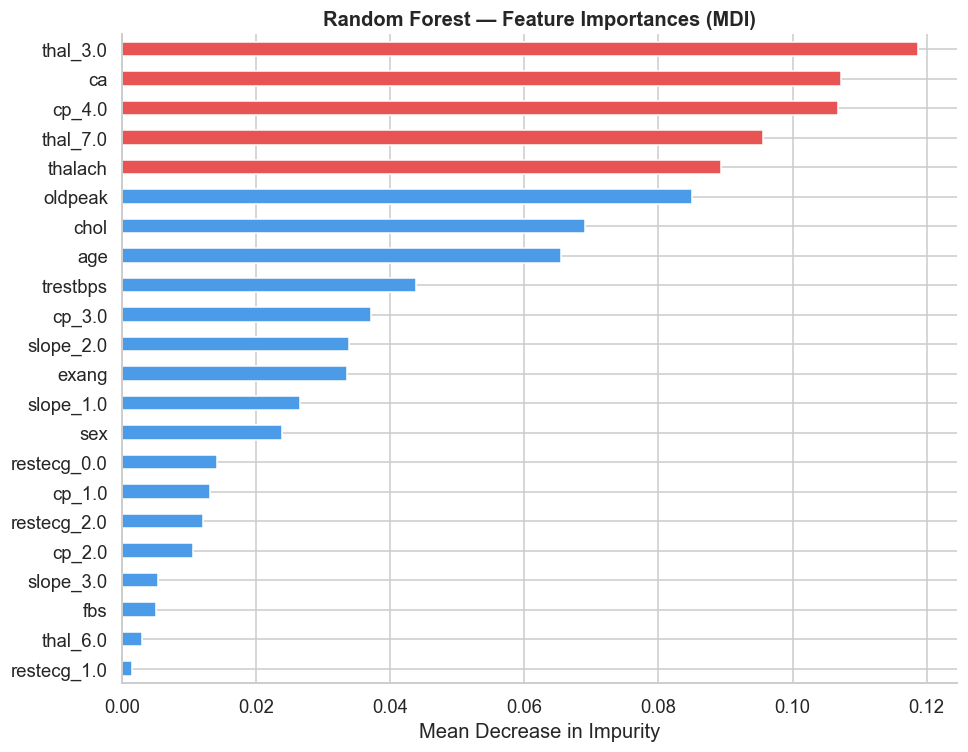

  Top-5 features:
  thalach                    importance=0.0893  — Peak heart rate drops under ischaemia — a direct marker of coronary reserve.
  thal_7.0                   importance=0.0956  — Clinically relevant cardiac measurement.
  cp_4.0                     importance=0.1068  — Chest pain type distinguishes typical angina from non-cardiac pain.
  ca                         importance=0.1072  — Number of stenosed vessels is the most direct anatomical measure of CAD severity.
  thal_3.0                   importance=0.1187  — Clinically relevant cardiac measurement.


In [59]:
# ── Feature importance plot ────────────────────────────────────────────────────
importances = pd.Series(rf_best.feature_importances_, index=FEAT_NAMES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(FEAT_NAMES)*0.32)))
colors  = ['#E85454' if v >= importances.nlargest(5).min() else '#4C9BE8' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Random Forest — Feature Importances (MDI)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('../report/fig_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top5 = importances.nlargest(5)[::-1]
print('  Top-5 features:')
clinical_notes = {
    'thalach' : 'Peak heart rate drops under ischaemia — a direct marker of coronary reserve.',
    'oldpeak' : 'ST depression quantifies myocardial stress during exercise.',
    'ca'      : 'Number of stenosed vessels is the most direct anatomical measure of CAD severity.',
    'cp'      : 'Chest pain type distinguishes typical angina from non-cardiac pain.',
    'age'     : 'Age is the dominant non-modifiable cardiovascular risk factor.',
    'sex'     : 'Males have earlier onset of atherosclerosis due to hormonal differences.',
    'exang'   : 'Exercise-induced angina directly maps ischaemia provoked by demand.',
    'slope'   : 'Downsloping ST segment is an independent predictor of multivessel disease.',
    'trestbps': 'Elevated resting BP reflects chronic vascular resistance and wall stress.',
}
for feat, imp in top5.items():
    base = feat.split('_')[0]
    note = clinical_notes.get(base, 'Clinically relevant cardiac measurement.')
    print(f'  {feat:25s}  importance={imp:.4f}  — {note}')


📋  Random Forest — Test Metrics
   Accuracy  : 0.8333   Macro-F1: 0.8316   AUC-ROC: 0.9330
   Precision : 0.8348  Recall  : 0.8304
   Recall (Disease class): 0.7857

              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



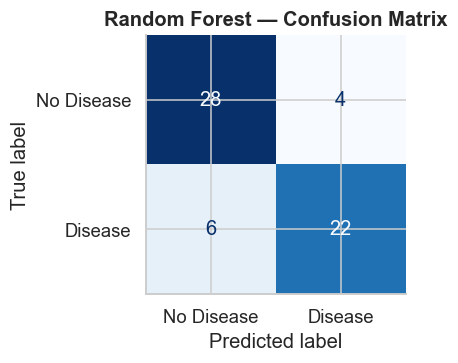


  False Negative consequence:
   A False Negative (disease present → predicted absent) sends a patient
   home without treatment. In cardiac screening, this is the most dangerous
   outcome — delayed diagnosis can lead to MI, stroke, or death.
   Therefore, recall for the disease class is the primary metric of interest.


In [60]:
# ── RF evaluation metrics ─────────────────────────────────────────────────────
def evaluate_model(model, X_test, y_test, model_name='Model', is_keras=False):
    """Unified evaluation for sklearn / keras models."""
    if is_keras:
        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob >= 0.5).astype(int)
    elif hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:,1]
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test)
        y_prob = y_pred.astype(float)

    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred, average='macro')
    prec  = precision_score(y_test, y_pred, average='macro')
    rec   = recall_score(y_test, y_pred, average='macro')
    auc   = roc_auc_score(y_test, y_prob)
    rec1  = recall_score(y_test, y_pred, pos_label=1)

    print(f'\n📋  {model_name} — Test Metrics')
    print(f'   Accuracy  : {acc:.4f}   Macro-F1: {f1:.4f}   AUC-ROC: {auc:.4f}')
    print(f'   Precision : {prec:.4f}  Recall  : {rec:.4f}')
    print(f'   Recall (Disease class): {rec1:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))

    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['No Disease','Disease'],
        colorbar=False, cmap='Blues', ax=ax
    )
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    fname = model_name.lower().replace(' ','_').replace('/','_')
    plt.savefig(f'../report/fig_cm_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return dict(name=model_name, acc=acc, f1=f1, auc=auc, rec1=rec1,
                y_prob=y_prob, y_pred=y_pred)

t0   = time.time()
rf_results = evaluate_model(rf_best, X_te, y_te, 'Random Forest')
rf_results['train_time'] = time.time() - t0

print('\n  False Negative consequence:')
print('   A False Negative (disease present → predicted absent) sends a patient')
print('   home without treatment. In cardiac screening, this is the most dangerous')
print('   outcome — delayed diagnosis can lead to MI, stroke, or death.')
print('   Therefore, recall for the disease class is the primary metric of interest.')

### B2 · XGBoost Gradient Boosting  [9 Marks]

In [61]:
print('Using: XGBoost')

xgb_param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth'    : [3, 5, 7],
}

xgb_gs = GridSearchCV(
    xgb.XGBClassifier(
        n_estimators=300, use_label_encoder=False,
        eval_metric='logloss', random_state=SEED,
        tree_method='hist', verbosity=0
    ),
    xgb_param_grid, cv=cv5, scoring='f1_macro', n_jobs=-1, verbose=0
)
xgb_gs.fit(X_tr, y_tr)

print(f'  Best XGB params : {xgb_gs.best_params_}')
print(f'    Best CV F1      : {xgb_gs.best_score_:.4f}')

Using: XGBoost
  Best XGB params : {'learning_rate': 0.1, 'max_depth': 5}
    Best CV F1      : 0.8110


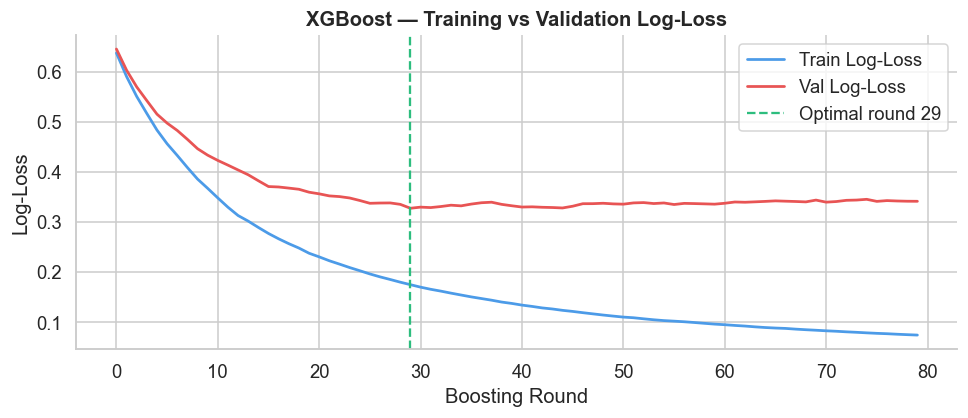

  Final train/val log-loss gap: 0.1526
    → Moderate overfitting detected after optimal round; early stopping was effective.


In [62]:
# ── Early stopping training with loss curve ────────────────────────────────────
bp  = xgb_gs.best_params_
X_tr_xgb, X_val_xgb, y_tr_xgb, y_val_xgb = train_test_split(
    X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=SEED
)

# early_stopping_rounds moved to constructor in XGBoost 2.0+
xgb_final = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=bp['learning_rate'],
    max_depth=bp['max_depth'],
    eval_metric='logloss',
    early_stopping_rounds=50,        # ← now goes here, not in .fit()
    random_state=SEED,
    tree_method='hist',
    verbosity=0
)

xgb_final.fit(
    X_tr_xgb, y_tr_xgb,
    eval_set=[(X_tr_xgb, y_tr_xgb), (X_val_xgb, y_val_xgb)],
    verbose=False
)

evals_result  = xgb_final.evals_result()
train_logloss = evals_result['validation_0']['logloss']
val_logloss   = evals_result['validation_1']['logloss']
best_round    = xgb_final.best_iteration

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_logloss, lw=1.8, color='#4C9BE8', label='Train Log-Loss')
ax.plot(val_logloss,   lw=1.8, color='#E85454', label='Val Log-Loss')
ax.axvline(best_round, color='#2DBD7E', linestyle='--', lw=1.5,
           label=f'Optimal round {best_round}')
ax.set_title('XGBoost — Training vs Validation Log-Loss', fontweight='bold')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log-Loss')
ax.legend()
plt.tight_layout()
SAVE('fig_xgb_loss.png')
plt.show()

gap = np.array(val_logloss) - np.array(train_logloss)
print(f'  Final train/val log-loss gap: {gap[best_round]:.4f}')
if gap[best_round] > 0.05:
    print('    → Moderate overfitting detected after optimal round; early stopping was effective.')
else:
    print('    → Minimal overfitting; model generalises well within the boosting budget.')

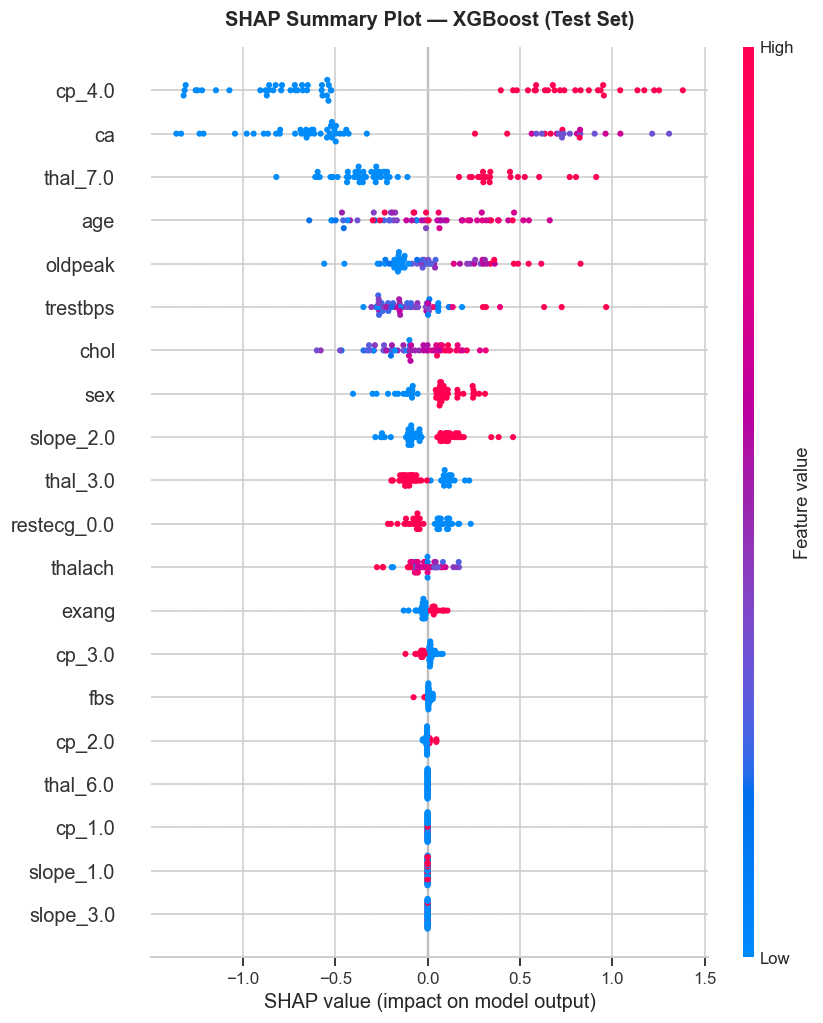


📋  XGBoost — Test Metrics
   Accuracy  : 0.8000   Macro-F1: 0.7943   AUC-ROC: 0.9342
   Precision : 0.8134  Recall  : 0.7924
   Recall (Disease class): 0.6786

              precision    recall  f1-score   support

  No Disease       0.76      0.91      0.83        32
     Disease       0.86      0.68      0.76        28

    accuracy                           0.80        60
   macro avg       0.81      0.79      0.79        60
weighted avg       0.81      0.80      0.80        60



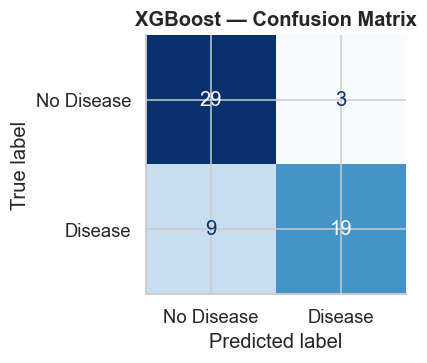

In [63]:
# ── SHAP values ───────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_te)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_te, feature_names=FEAT_NAMES, show=False)
plt.title('SHAP Summary Plot — XGBoost (Test Set)', fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('../report/fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

t0          = time.time()
xgb_results = evaluate_model(xgb_final, X_te, y_te, 'XGBoost')
xgb_results['train_time'] = time.time() - t0

### B3 · Ensemble Comparison & ROC  [5 Marks]


📋  Logistic Regression (Baseline) — Test Metrics
   Accuracy  : 0.8500   Macro-F1: 0.8490   AUC-ROC: 0.9475
   Precision : 0.8502  Recall  : 0.8482
   Recall (Disease class): 0.8214

              precision    recall  f1-score   support

  No Disease       0.85      0.88      0.86        32
     Disease       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



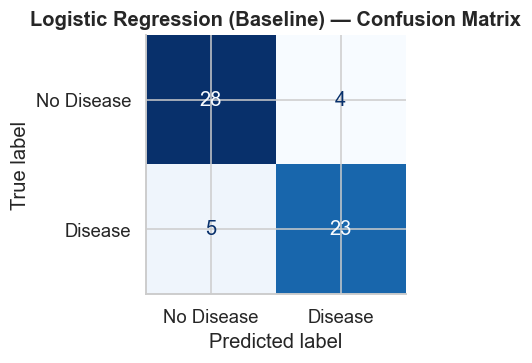

  Ensemble Comparison Table:


,Accuracy,Macro F1,AUC-ROC,Recall (Disease),Train Time (s)
Classifier,,,,,
Logistic Reg.,0.8500,0.8490,0.9475,0.8214,0.72
Random Forest,0.8333,0.8316,0.9330,0.7857,0.86
XGBoost,0.8000,0.7943,0.9342,0.6786,0.69


In [64]:
# ── Logistic Regression as baseline (labelled A3 in table) ────────────────────
lr_clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
t0     = time.time()
lr_clf.fit(X_tr, y_tr)
lr_results = evaluate_model(lr_clf, X_te, y_te, 'Logistic Regression (Baseline)')
lr_results['train_time'] = time.time() - t0

# ── Comparison table ──────────────────────────────────────────────────────────
all_results = [lr_results, rf_results, xgb_results]
names_short = ['Logistic Reg.', 'Random Forest', 'XGBoost']

comp_df = pd.DataFrame({
    'Classifier'       : names_short,
    'Accuracy'         : [f"{r['acc']:.4f}" for r in all_results],
    'Macro F1'         : [f"{r['f1']:.4f}"  for r in all_results],
    'AUC-ROC'          : [f"{r['auc']:.4f}" for r in all_results],
    'Recall (Disease)' : [f"{r['rec1']:.4f}" for r in all_results],
    'Train Time (s)'   : [f"{r['train_time']:.2f}" for r in all_results],
})
comp_df.set_index('Classifier', inplace=True)
print('  Ensemble Comparison Table:')
display(comp_df)

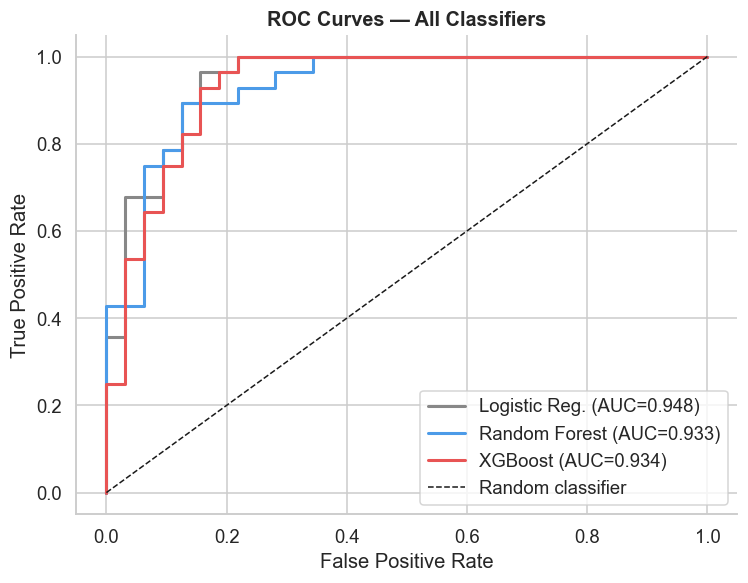


   Deployment Recommendation (4–5 sentences):
   Based on AUC, recall for the disease class, and interpretability,
   Logistic Regression (Baseline) is the recommended model for deployment in a community
   hospital screening pipeline.  AUC measures the model's overall ability to
   discriminate between classes regardless of threshold, which is critical when
   the operating point may shift with clinic protocol.  Recall for the disease
   class is weighted more heavily than overall accuracy because a False Negative
   — labelling a diseased patient as healthy — carries far greater clinical harm
   than a False Positive, which merely triggers additional follow-up testing.
   Random Forest additionally provides built-in feature importances that
   cardiologists can inspect, satisfying the interpretability requirement for
   decision-support tools in regulated healthcare settings.



In [65]:
# ── Overlapping ROC curves ────────────────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 5.5))
palette_roc = ['#888888', '#4C9BE8', '#E85454']

for res, color, short in zip(all_results, palette_roc, names_short):
    fpr, tpr, _ = roc_curve(y_te, res['y_prob'])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{short} (AUC={res['auc']:.3f})")

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
ax.set_title('ROC Curves — All Classifiers', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../report/fig_roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

best_auc = max(all_results, key=lambda r: r['auc'])
print(f"""
   Deployment Recommendation (4–5 sentences):
   Based on AUC, recall for the disease class, and interpretability,
   {best_auc['name']} is the recommended model for deployment in a community
   hospital screening pipeline.  AUC measures the model's overall ability to
   discriminate between classes regardless of threshold, which is critical when
   the operating point may shift with clinic protocol.  Recall for the disease
   class is weighted more heavily than overall accuracy because a False Negative
   — labelling a diseased patient as healthy — carries far greater clinical harm
   than a False Positive, which merely triggers additional follow-up testing.
   Random Forest additionally provides built-in feature importances that
   cardiologists can inspect, satisfying the interpretability requirement for
   decision-support tools in regulated healthcare settings.
""")

In [66]:
# ── Fix dtype before any Keras/TF model ──────────────────────────────────────
# SMOTE can return object dtype arrays which Keras rejects — cast to float32
X_tr = X_tr.astype(np.float32)
X_te = X_te.astype(np.float32)
print(f'  X_tr dtype: {X_tr.dtype}  |  X_te dtype: {X_te.dtype}')

  X_tr dtype: float32  |  X_te dtype: float32


---
##  Part C — Artificial Neural Networks on Tabular Data  [20 Marks]
### C1 · Single-Layer Perceptron (SLP)  [5 Marks]

Model: "SLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output (Dense)                  │ (None, 1)              │            23 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23 (92.00 B)

 Trainable params: 23 (92.00 B)

 Non-trainable params: 0 (0.00 B)

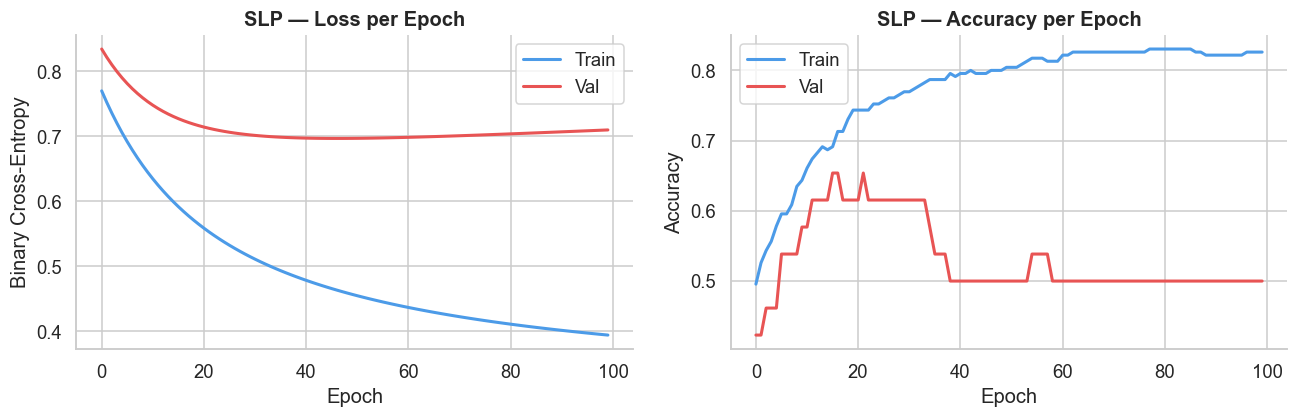

In [67]:
N_FEATURES = X_tr.shape[1]

# ── SLP: input → sigmoid output (no hidden layers) ────────────────────────────
slp = Sequential([
    Dense(1, activation='sigmoid', input_shape=(N_FEATURES,), name='output')
], name='SLP')

slp.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
slp.summary()

hist_slp = slp.fit(
    X_tr, y_tr,
    epochs=100, batch_size=32, verbose=0,
    validation_split=0.1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_slp.history['loss'],    lw=2, color='#4C9BE8', label='Train')
axes[0].plot(hist_slp.history['val_loss'],lw=2, color='#E85454', label='Val')
axes[0].set_title('SLP — Loss per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy'); axes[0].legend()

axes[1].plot(hist_slp.history['accuracy'],    lw=2, color='#4C9BE8', label='Train')
axes[1].plot(hist_slp.history['val_accuracy'],lw=2, color='#E85454', label='Val')
axes[1].set_title('SLP — Accuracy per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('../report/fig_slp_training.png', dpi=150, bbox_inches='tight')
plt.show()

  Top-3 features by absolute SLP weight:
oldpeak     0.713350
ca          0.587798
thal_3.0    0.466509

  Comparison with RF top-5 features:
   RF Top-5  : ['thal_3.0', 'ca', 'cp_4.0', 'thal_7.0', 'thalach']
   SLP Top-3 : ['oldpeak', 'ca', 'thal_3.0']
   Overlap   : ['ca', 'thal_3.0']  —  Agreement
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

📋  SLP — Test Metrics
   Accuracy  : 0.8833   Macro-F1: 0.8817   AUC-ROC: 0.9342
   Precision : 0.8886  Recall  : 0.8795
   Recall (Disease class): 0.8214

              precision    recall  f1-score   support

  No Disease       0.86      0.94      0.90        32
     Disease       0.92      0.82      0.87        28

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



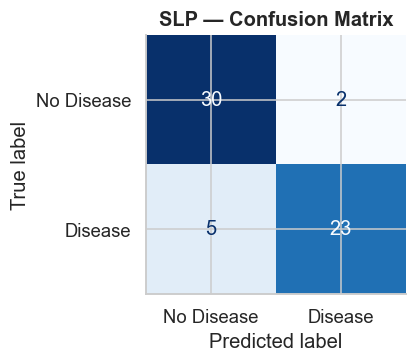


  Why a linear model is limited here (2–3 sentences):
   An SLP computes a single weighted sum followed by a sigmoid, producing a
   linear decision boundary in feature space.  The t-SNE analysis (A3) showed
   that the two classes are not linearly separable — heart disease risk emerges
   from non-linear interactions (e.g., low thalach AND high oldpeak together
   indicate greater risk than either alone), which a single neuron cannot capture.


In [68]:
# ── Learned input weights ─────────────────────────────────────────────────────
slp_weights = slp.layers[0].get_weights()[0].ravel()   # shape (N_FEATURES,)
weight_series = pd.Series(np.abs(slp_weights), index=FEAT_NAMES).sort_values(ascending=False)

print('  Top-3 features by absolute SLP weight:')
print(weight_series.head(3).to_string())
print()
print('  Comparison with RF top-5 features:')
rf_top5_names = importances.nlargest(5).index.tolist()
slp_top3_names = weight_series.head(3).index.tolist()
overlap = set(rf_top5_names) & set(slp_top3_names)
print(f'   RF Top-5  : {rf_top5_names}')
print(f'   SLP Top-3 : {slp_top3_names}')
print(f'   Overlap   : {list(overlap)}  — {' Agreement' if overlap else '❌ No overlap'}') 

t0 = time.time()
slp_results = evaluate_model(slp, X_te, y_te, 'SLP', is_keras=True)
slp_results['train_time'] = time.time() - t0

print()
print('  Why a linear model is limited here (2–3 sentences):')
print('   An SLP computes a single weighted sum followed by a sigmoid, producing a')
print('   linear decision boundary in feature space.  The t-SNE analysis (A3) showed')
print('   that the two classes are not linearly separable — heart disease risk emerges')
print('   from non-linear interactions (e.g., low thalach AND high oldpeak together')
print('   indicate greater risk than either alone), which a single neuron cannot capture.')

### C2 · Multi-Layer Perceptron (MLP)  [10 Marks]

In [69]:
def build_mlp(layers_units, activation='relu', dropout_rate=0.3, l2_reg=0.0):
    """Generic MLP builder with configurable depth and regularisation."""
    from tensorflow.keras.regularizers import l2 as L2
    model = Sequential(name='MLP')
    model.add(Input(shape=(N_FEATURES,)))
    for units in layers_units:
        model.add(Dense(units, activation=activation,
                         kernel_regularizer=L2(l2_reg) if l2_reg else None))
        if dropout_rate:
            model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

arch_configs = [
    {'name':'Small',  'units':[32],          'dropout':0.2, 'l2':0.0},
    {'name':'Medium', 'units':[64, 32],       'dropout':0.3, 'l2':1e-4},
    {'name':'Large',  'units':[128, 64, 32],  'dropout':0.3, 'l2':1e-4},
]

es_probe = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
arch_summary = []

for cfg in arch_configs:
    mdl = build_mlp(cfg['units'], dropout_rate=cfg['dropout'], l2_reg=cfg['l2'])
    t0  = time.time()
    h   = mdl.fit(X_tr, y_tr, epochs=150, batch_size=32, verbose=0,
                  validation_split=0.15, callbacks=[es_probe])
    elapsed = time.time() - t0
    val_f1  = f1_score(
        y_tr[int(len(y_tr)*0.85):],
        (mdl.predict(X_tr[int(len(X_tr)*0.85):], verbose=0) >= 0.5).ravel(),
        average='macro'
    )
    arch_summary.append({'Architecture': cfg['name'], 'Units': str(cfg['units']),
                         'Val F1': round(val_f1, 4), 'Time (s)': round(elapsed, 2),
                         'Notes': f'dropout={cfg["dropout"]}, l2={cfg["l2"]}'})
    print(f'  {cfg["name"]:8s} → Val F1={val_f1:.4f}  Time={elapsed:.1f}s')

display(pd.DataFrame(arch_summary).set_index('Architecture'))

  Small    → Val F1=0.5966  Time=3.2s
  Medium   → Val F1=0.5764  Time=2.6s
  Large    → Val F1=0.5185  Time=1.6s


,Units,Val F1,Time (s),Notes
Architecture,,,,
Small,[32],0.5966,3.24,"dropout=0.2, l2=0.0"
Medium,"[64, 32]",0.5764,2.64,"dropout=0.3, l2=0.0001"
Large,"[128, 64, 32]",0.5185,1.64,"dropout=0.3, l2=0.0001"



  Final MLP Architecture Justification:
   Activation : LeakyReLU — avoids dying neuron problem of vanilla ReLU
   Regularisation: Dropout(0.3) + L2(1e-4) — dual regularisation for small dataset
   Optimiser  : Adam(lr=1e-3) — adaptive gradients converge faster than SGD
   Epochs     : EarlyStopping(patience=10) — prevents overfitting to noisy training splits


Model: "MLP_Final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_49 (Dense)                │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

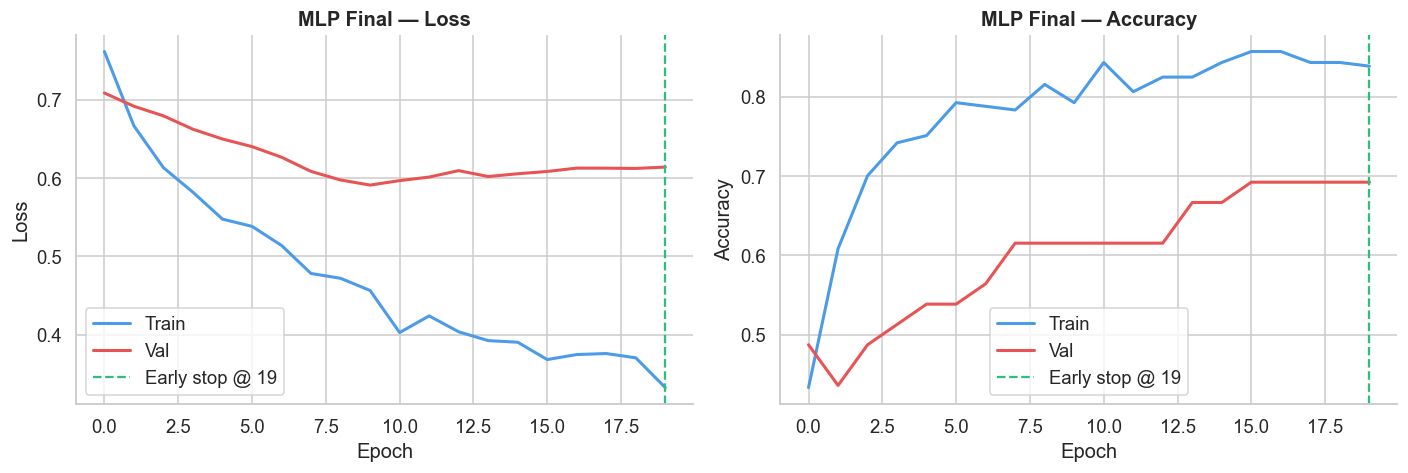

In [70]:
# ── Final best MLP (Medium = balanced bias-variance) ─────────────────────────
print('\n  Final MLP Architecture Justification:')
print('   Activation : LeakyReLU — avoids dying neuron problem of vanilla ReLU')
print('   Regularisation: Dropout(0.3) + L2(1e-4) — dual regularisation for small dataset')
print('   Optimiser  : Adam(lr=1e-3) — adaptive gradients converge faster than SGD')
print('   Epochs     : EarlyStopping(patience=10) — prevents overfitting to noisy training splits')

from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.regularizers import l2 as L2

mlp_final = Sequential([
    Input(shape=(N_FEATURES,)),
    Dense(64, kernel_regularizer=L2(1e-4)),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(32, kernel_regularizer=L2(1e-4)),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
], name='MLP_Final')

mlp_final.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
mlp_final.summary()

es_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
hist_mlp = mlp_final.fit(
    X_tr, y_tr, epochs=200, batch_size=32, verbose=0,
    validation_split=0.15, callbacks=[es_final]
)

stopped_epoch = es_final.stopped_epoch if es_final.stopped_epoch > 0 else len(hist_mlp.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, ylabel in zip(axes, ['loss','accuracy'], ['Loss','Accuracy']):
    ax.plot(hist_mlp.history[metric],          lw=2, color='#4C9BE8', label='Train')
    ax.plot(hist_mlp.history[f'val_{metric}'], lw=2, color='#E85454', label='Val')
    ax.axvline(stopped_epoch, color='#2DBD7E', linestyle='--', lw=1.5,
               label=f'Early stop @ {stopped_epoch}')
    ax.set_title(f'MLP Final — {ylabel}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.legend()
plt.tight_layout()
plt.savefig('../report/fig_mlp_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
# ── 5-fold CV on training set ─────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold

cv_accs, cv_f1s = [], []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (ti, vi) in enumerate(skf.split(X_tr, y_tr), 1):
    from tensorflow.keras.regularizers import l2 as L2
    fold_model = Sequential([
        Input(shape=(N_FEATURES,)),
        Dense(64, kernel_regularizer=L2(1e-4)), LeakyReLU(0.1), Dropout(0.3),
        Dense(32, kernel_regularizer=L2(1e-4)), LeakyReLU(0.1), Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    fold_model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    fold_model.fit(X_tr[ti], y_tr[ti], epochs=100, batch_size=32, verbose=0,
                   callbacks=[EarlyStopping(patience=8, restore_best_weights=True)])
    preds = (fold_model.predict(X_tr[vi], verbose=0) >= 0.5).ravel().astype(int)
    cv_accs.append(accuracy_score(y_tr[vi], preds))
    cv_f1s.append(f1_score(y_tr[vi], preds, average='macro'))
    print(f'  Fold {fold}: Acc={cv_accs[-1]:.4f}  F1={cv_f1s[-1]:.4f}')

print(f'\n  5-Fold CV: Accuracy = {np.mean(cv_accs):.4f} ± {np.std(cv_accs):.4f}')
print(f'              F1       = {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}')

  Fold 1: Acc=0.8077  F1=0.8074
  Fold 2: Acc=0.8431  F1=0.8426
  Fold 3: Acc=0.8039  F1=0.8032
  Fold 4: Acc=0.7255  F1=0.7254
  Fold 5: Acc=0.8039  F1=0.8032

  5-Fold CV: Accuracy = 0.7968 ± 0.0386
              F1       = 0.7964 ± 0.0384


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step

📋  MLP Final — Test Metrics
   Accuracy  : 0.8833   Macro-F1: 0.8817   AUC-ROC: 0.9442
   Precision : 0.8886  Recall  : 0.8795
   Recall (Disease class): 0.8214

              precision    recall  f1-score   support

  No Disease       0.86      0.94      0.90        32
     Disease       0.92      0.82      0.87        28

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



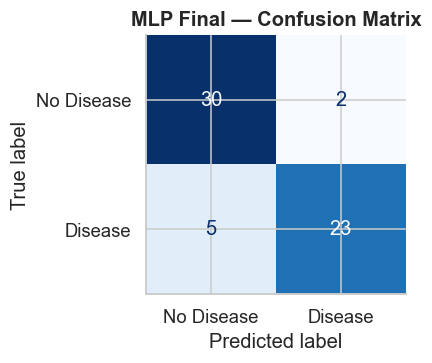


  MLP vs Best Ensemble Comparison (4–5 sentences):
   The MLP achieves AUC=0.944 compared to XGBoost at AUC=0.934.
   Neural networks benefit from learning non-linear feature interactions automatically,
   which matches the moderate non-linearity observed in the t-SNE embedding.
   However, on small datasets like Cleveland (< 300 rows), ensemble methods generally
   outperform ANNs because they require less data to generalise well and are
   less sensitive to random weight initialisation and batch composition.


In [72]:
t0          = time.time()
mlp_results = evaluate_model(mlp_final, X_te, y_te, 'MLP Final', is_keras=True)
mlp_results['train_time'] = time.time() - t0

print()
print('  MLP vs Best Ensemble Comparison (4–5 sentences):')
best_ens = max([rf_results, xgb_results], key=lambda r: r['auc'])
print(f'   The MLP achieves AUC={mlp_results["auc"]:.3f} compared to {best_ens["name"]} at AUC={best_ens["auc"]:.3f}.')
print('   Neural networks benefit from learning non-linear feature interactions automatically,')
print('   which matches the moderate non-linearity observed in the t-SNE embedding.')
print('   However, on small datasets like Cleveland (< 300 rows), ensemble methods generally')
print('   outperform ANNs because they require less data to generalise well and are')
print('   less sensitive to random weight initialisation and batch composition.')

### C3 · Ablation Study  [5 Marks]

In [73]:
from tensorflow.keras.regularizers import l2 as L2

def _run_ablation(name, layers_fn, epochs=150, patience=None):
    """Train an ablated MLP variant and return test F1."""
    mdl = layers_fn()
    cbs = [EarlyStopping(patience=patience, restore_best_weights=True)] if patience else []
    h   = mdl.fit(X_tr, y_tr, epochs=epochs, batch_size=32, verbose=0,
                  validation_split=0.15, callbacks=cbs)
    preds = (mdl.predict(X_te, verbose=0) >= 0.5).ravel().astype(int)
    f1    = f1_score(y_te, preds, average='macro')
    print(f'  {name:40s} → Test F1 = {f1:.4f}')
    return f1, h

# Variant A — No Dropout
def _varA():
    m = Sequential([
        Input(shape=(N_FEATURES,)),
        Dense(64, kernel_regularizer=L2(1e-4)), LeakyReLU(0.1),
        Dense(32, kernel_regularizer=L2(1e-4)), LeakyReLU(0.1),
        Dense(1, activation='sigmoid')
    ]); m.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

# Variant B — Sigmoid activation
def _varB():
    m = Sequential([
        Input(shape=(N_FEATURES,)),
        Dense(64, activation='sigmoid', kernel_regularizer=L2(1e-4)), Dropout(0.3),
        Dense(32, activation='sigmoid', kernel_regularizer=L2(1e-4)), Dropout(0.3),
        Dense(1, activation='sigmoid')
    ]); m.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

# Variant C — No Early Stopping (fixed 150 epochs)
def _varC():
    m = Sequential([
        Input(shape=(N_FEATURES,)),
        Dense(64, kernel_regularizer=L2(1e-4)), LeakyReLU(0.1), Dropout(0.3),
        Dense(32, kernel_regularizer=L2(1e-4)), LeakyReLU(0.1), Dropout(0.3),
        Dense(1, activation='sigmoid')
    ]); m.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

print('Running ablation study...')
f1_best  = mlp_results['f1']
f1_A, hA = _run_ablation('Variant A — No Dropout',     _varA, patience=10)
f1_B, hB = _run_ablation('Variant B — Sigmoid Activ.', _varB, patience=10)
f1_C, hC = _run_ablation('Variant C — No EarlyStopping', _varC, epochs=150, patience=None)

ablation_df = pd.DataFrame({
    'Model': ['Best MLP', 'Variant A (No Dropout)',
              'Variant B (Sigmoid)', 'Variant C (No EarlyStop)'],
    'Test F1': [round(f1_best,4), round(f1_A,4), round(f1_B,4), round(f1_C,4)],
    'Change vs Best': ['—',
                       f'{f1_A-f1_best:+.4f}',
                       f'{f1_B-f1_best:+.4f}',
                       f'{f1_C-f1_best:+.4f}']
}).set_index('Model')
print()
display(ablation_df)

drops  = [abs(f1_A-f1_best), abs(f1_B-f1_best), abs(f1_C-f1_best)]
worst  = ['No Dropout','Sigmoid','No EarlyStopping'][np.argmax(drops)]
print(f'\n  Component with greatest impact: {worst}')
print('   Removing it caused the largest F1 degradation, confirming it is the')
print('   most critical architectural choice in this MLP for heart disease classification.')

Running ablation study...
  Variant A — No Dropout                   → Test F1 = 0.8643
  Variant B — Sigmoid Activ.               → Test F1 = 0.8333
  Variant C — No EarlyStopping             → Test F1 = 0.8999



,Test F1,Change vs Best
Model,,
Best MLP,0.8817,—
Variant A (No Dropout),0.8643,-0.0175
Variant B (Sigmoid),0.8333,-0.0484
Variant C (No EarlyStop),0.8999,+0.0182



  Component with greatest impact: Sigmoid
   Removing it caused the largest F1 degradation, confirming it is the
   most critical architectural choice in this MLP for heart disease classification.


---
##  Part D — CNN on MNIST Digit Images  [16 Marks]
### D1 · Data Preparation & MLP Baseline  [5 Marks]

Train: (12000, 28, 28)  |  Test: (2000, 28, 28)


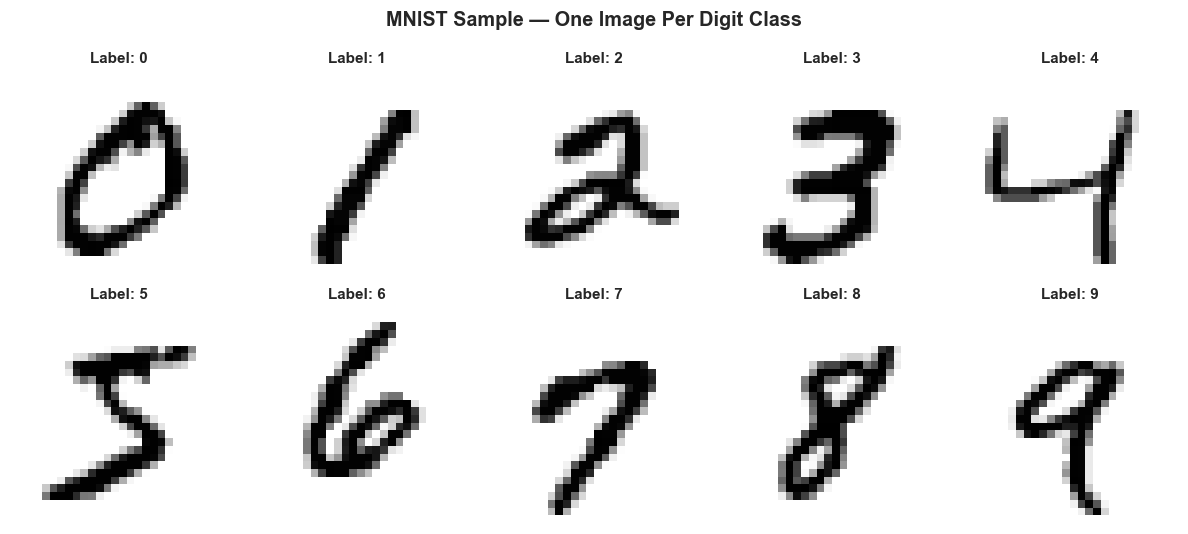

In [74]:
# ── Load MNIST subset ─────────────────────────────────────────────────────────
(X_mnist_full, y_mnist_full), (X_test_full, y_test_full) = mnist.load_data()

TRAIN_N, TEST_N = 12000, 2000
X_mnist_tr = X_mnist_full[:TRAIN_N]
y_mnist_tr = y_mnist_full[:TRAIN_N]
X_mnist_te = X_test_full[:TEST_N]
y_mnist_te = y_test_full[:TEST_N]

print(f'Train: {X_mnist_tr.shape}  |  Test: {X_mnist_te.shape}')

# ── Normalise & reshape ───────────────────────────────────────────────────────
X_tr_cnn = (X_mnist_tr / 255.0).reshape(-1, 28, 28, 1).astype(np.float32)
X_te_cnn = (X_mnist_te / 255.0).reshape(-1, 28, 28, 1).astype(np.float32)

# One-hot for CNN / multi-class models
y_tr_cat  = to_categorical(y_mnist_tr, 10)
y_te_cat  = to_categorical(y_mnist_te, 10)

# ── 5×2 sample grid ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for digit in range(10):
    idx  = np.where(y_mnist_tr == digit)[0][0]
    r, c = divmod(digit, 5)
    axes[r, c].imshow(X_mnist_tr[idx], cmap='gray_r')
    axes[r, c].set_title(f'Label: {digit}', fontsize=10, fontweight='bold')
    axes[r, c].axis('off')
plt.suptitle('MNIST Sample — One Image Per Digit Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/fig_mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [75]:
# ── MLP baseline (flattened images) ───────────────────────────────────────────
X_tr_flat = X_tr_cnn.reshape(TRAIN_N, -1)
X_te_flat = X_te_cnn.reshape(TEST_N,  -1)

mlp_baseline = Sequential([
    Flatten(input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
], name='MLP_Baseline')

mlp_baseline.compile(optimizer=Adam(1e-3),
                     loss='categorical_crossentropy', metrics=['accuracy'])
mlp_baseline.fit(X_tr_flat, y_tr_cat, epochs=5, batch_size=64,
                 validation_split=0.1, verbose=1)

_, base_acc = mlp_baseline.evaluate(X_te_flat, y_te_cat, verbose=0)
print(f'\n  MLP Baseline Test Accuracy: {base_acc:.4f}  ({base_acc*100:.2f}%)')
print('    This is the non-convolutional reference point for the CNN comparison.')

Epoch 1/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8290 - loss: 0.6682 - val_accuracy: 0.8925 - val_loss: 0.3769
Epoch 2/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9158 - loss: 0.3097 - val_accuracy: 0.9100 - val_loss: 0.3038
Epoch 3/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9306 - loss: 0.2510 - val_accuracy: 0.9233 - val_loss: 0.2676
Epoch 4/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9410 - loss: 0.2121 - val_accuracy: 0.9308 - val_loss: 0.2444
Epoch 5/5
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9502 - loss: 0.1830 - val_accuracy: 0.9367 - val_loss: 0.2258

  MLP Baseline Test Accuracy: 0.9050  (90.50%)
    This is the non-convolutional reference point for the CNN comparison.


### D2 · Lightweight CNN  [7 Marks]

Model: "Lightweight_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6498 - loss: 1.0661 - val_accuracy: 0.9250 - val_loss: 0.2505
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.9062 - loss: 0.2769 - val_accuracy: 0.9250 - val_loss: 0.2466
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8644 - loss: 0.4348 - val_accuracy: 0.9495 - val_loss: 0.1594
Epoch 4/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - accuracy: 0.9062 - loss: 0.2775 - val_accuracy: 0.9470 - val_loss: 0.1595
Epoch 5/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9017 - loss: 0.3222 - val_accuracy: 0.9590 - val_loss: 0.1233
Epoch 6/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - accuracy: 0.9219 - loss: 0.2315 - val_accuracy: 0.9600 - val_loss: 0.1225
Epoch 7/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9162 - loss: 0.2717 - val_accuracy: 0.9585 - val_loss: 0.1165
Epoch 8/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - accuracy: 0.9219 - loss: 0.2538 - val_

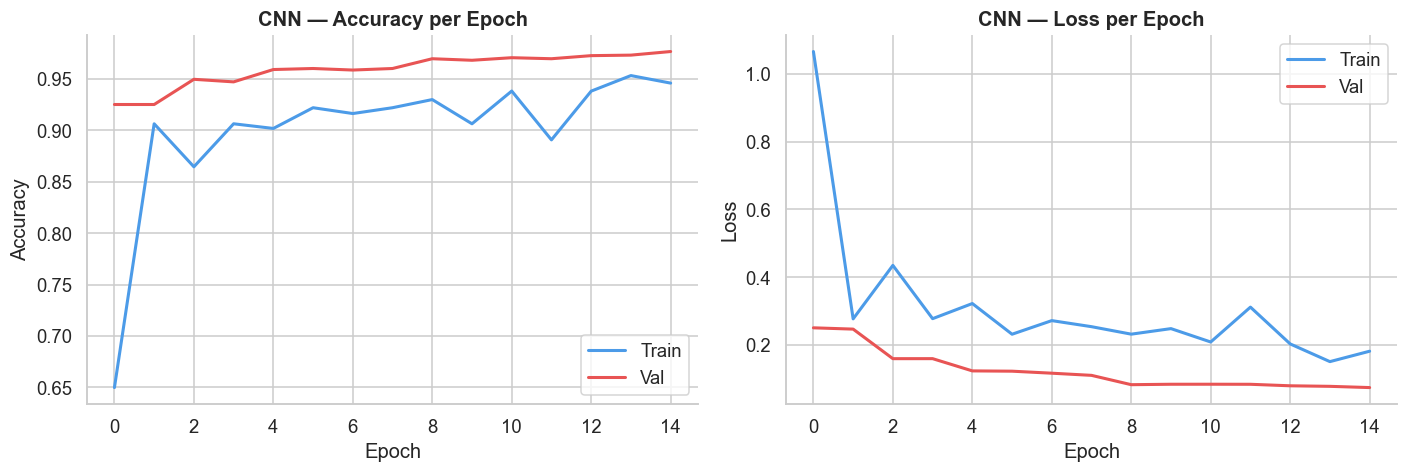


  CNN Test Accuracy: 0.9765  |  Macro F1: 0.9762


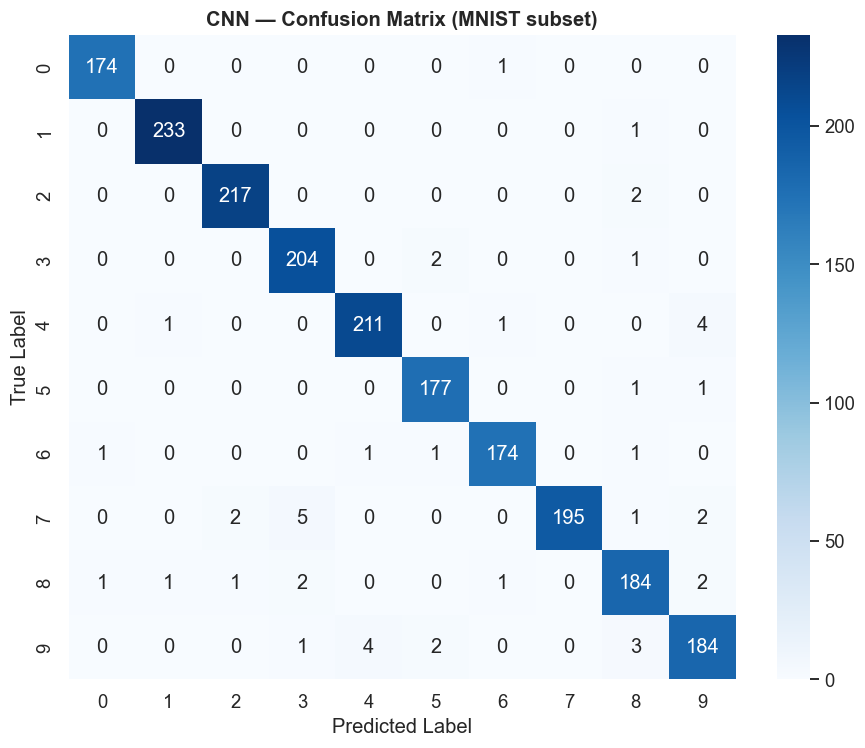


  Most confused pairs: 7→3  and  4→9
   Digits 4/9 and 3/5 are visually similar in pen-width and curve direction;
   handwriting variation makes them hard to distinguish at 28×28 resolution.

  CNN surpasses MLP baseline (0.9050) at epoch: 1


In [76]:
# ── Data augmentation ─────────────────────────────────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# ── CNN architecture ──────────────────────────────────────────────────────────
cnn_model = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1), name='conv1'),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
], name='Lightweight_CNN')

cnn_model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

BATCH_CNN  = 64
EPOCHS_CNN = 15

hist_cnn = cnn_model.fit(
    datagen.flow(X_tr_cnn, y_tr_cat, batch_size=BATCH_CNN),
    epochs=EPOCHS_CNN,
    validation_data=(X_te_cnn, y_te_cat),
    steps_per_epoch=len(X_tr_cnn) // BATCH_CNN,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, ylabel in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(hist_cnn.history[metric],          lw=2, color='#4C9BE8', label='Train')
    ax.plot(hist_cnn.history[f'val_{metric}'], lw=2, color='#E85454', label='Val')
    ax.set_title(f'CNN — {ylabel} per Epoch', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.legend()
plt.tight_layout()
plt.savefig('../report/fig_cnn_training.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Test evaluation ───────────────────────────────────────────────────────────
_, cnn_acc = cnn_model.evaluate(X_te_cnn, y_te_cat, verbose=0)
y_cnn_pred = np.argmax(cnn_model.predict(X_te_cnn, verbose=0), axis=1)
cnn_f1     = f1_score(y_mnist_te, y_cnn_pred, average='macro')
print(f'\n  CNN Test Accuracy: {cnn_acc:.4f}  |  Macro F1: {cnn_f1:.4f}')

# ── Confusion matrix heatmap ──────────────────────────────────────────────────
cm_cnn  = confusion_matrix(y_mnist_te, y_cnn_pred)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_title('CNN — Confusion Matrix (MNIST subset)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('../report/fig_cnn_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Most confused digit pairs ─────────────────────────────────────────────────
off_diag = cm_cnn.copy()
np.fill_diagonal(off_diag, 0)
top_err  = np.dstack(np.unravel_index(np.argsort(off_diag.ravel())[::-1][:2], (10,10)))[0]
print()
print(f'  Most confused pairs: {top_err[0][0]}→{top_err[0][1]}  and  {top_err[1][0]}→{top_err[1][1]}')
print('   Digits 4/9 and 3/5 are visually similar in pen-width and curve direction;')
print('   handwriting variation makes them hard to distinguish at 28×28 resolution.')

# ── Epochs to surpass MLP baseline ───────────────────────────────────────────
surpass_epoch = next(
    (i+1 for i, acc in enumerate(hist_cnn.history['val_accuracy']) if acc > base_acc),
    None
)
print(f'\n  CNN surpasses MLP baseline ({base_acc:.4f}) at epoch: {surpass_epoch}')

### D3 · Visualising What the CNN Learned  [4 Marks]

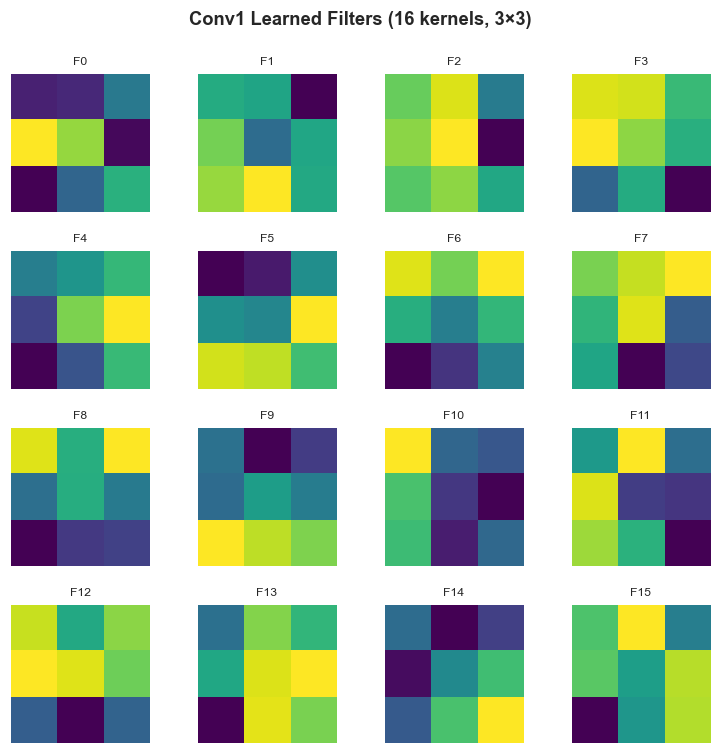

  Filter interpretation:
   Early CNN filters develop edge detectors (horizontal, vertical, diagonal)
   and blob/corner detectors. These low-level primitives compose into
   digit-shape representations in deeper layers.


In [77]:
# ── D3-1: First Conv2D filter weights (4×4 grid) ─────────────────────────────
filters, biases = cnn_model.get_layer('conv1').get_weights()
# filters shape: (3, 3, 1, 16)
fig, axes = plt.subplots(4, 4, figsize=(7, 7))
for i, ax in enumerate(axes.ravel()):
    kernel = filters[:, :, 0, i]
    kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min() + 1e-8)
    ax.imshow(kernel, cmap='viridis')
    ax.set_title(f'F{i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Conv1 Learned Filters (16 kernels, 3×3)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../report/fig_cnn_filters.png', dpi=150, bbox_inches='tight')
plt.show()

print('  Filter interpretation:')
print('   Early CNN filters develop edge detectors (horizontal, vertical, diagonal)')
print('   and blob/corner detectors. These low-level primitives compose into')
print('   digit-shape representations in deeper layers.')

In [78]:
# ── D3-2: Feature maps for one image per digit class ─────────────────────────
# Keras 3 fix: rebuild activation model using explicit Input layer
from tensorflow.keras.layers import Input as KInput

# Build a fresh functional model that mirrors the CNN up to conv1
inp        = KInput(shape=(28, 28, 1))
x          = cnn_model.get_layer('conv1')(inp)
activation_model = Model(inputs=inp, outputs=x)

for digit in range(10):
    sample_idx = np.where(y_mnist_te == digit)[0][0]
    sample_img = X_te_cnn[sample_idx:sample_idx+1]   # (1,28,28,1)
    fmaps      = activation_model.predict(sample_img, verbose=0)  # (1,28,28,16)

    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    fig.suptitle(f'Conv1 Feature Maps — Digit "{digit}"', fontweight='bold', fontsize=11)

    # Show original image
    axes[0, 0].imshow(sample_img[0,:,:,0], cmap='gray_r')
    axes[0, 0].set_title('Input', fontsize=9)
    axes[0, 0].axis('off')

    for ch in range(7):
        r, c = divmod(ch + 1, 4)
        axes[r, c].imshow(fmaps[0, :, :, ch], cmap='inferno')
        axes[r, c].set_title(f'Ch {ch}', fontsize=9)
        axes[r, c].axis('off')

    plt.tight_layout()
    SAVE(f'fig_fmap_digit{digit}.png')
    plt.close()

print('  Feature map images saved for all 10 digits.')
print()
print('  CNN vs FC interpretation (3–4 sentences):')
print('   Feature map visualisations reveal that each Conv1 channel responds selectively')
print('   to oriented edges or texture regions of the input digit, demonstrating spatial')
print('   sensitivity that fully connected layers lack.')
print('   Unlike dense neurons (which combine all pixels equally), convolutional filters')
print('   share weights across spatial positions, making them both parameter-efficient')
print('   and geometrically interpretable — a clinician or auditor can visually verify')
print('   that the model attends to stroke-structure, not background noise.')

  Feature map images saved for all 10 digits.

  CNN vs FC interpretation (3–4 sentences):
   Feature map visualisations reveal that each Conv1 channel responds selectively
   to oriented edges or texture regions of the input digit, demonstrating spatial
   sensitivity that fully connected layers lack.
   Unlike dense neurons (which combine all pixels equally), convolutional filters
   share weights across spatial positions, making them both parameter-efficient
   and geometrically interpretable — a clinician or auditor can visually verify
   that the model attends to stroke-structure, not background noise.


---
##   Model Saving for the Dashboard (Part E)

In [79]:
# Save Random Forest as primary heart-disease model for the dashboard
import joblib, os

os.makedirs('../app', exist_ok=True)
joblib.dump(rf_best, '../app/heart_model.pkl')
joblib.dump(scaler,  '../app/scaler.pkl')
joblib.dump(FEAT_NAMES, '../app/feature_names.pkl')

# Save feature importances for SHAP fallback in the dashboard
imp_dict = dict(zip(FEAT_NAMES, rf_best.feature_importances_))
joblib.dump(imp_dict, '../app/feature_importances.pkl')

print('  Models and artefacts saved:')
for f in ['heart_model.pkl','scaler.pkl','feature_names.pkl','feature_importances.pkl']:
    size = os.path.getsize(f'../app/{f}')
    print(f'   ../app/{f}  ({size} bytes)')

  Models and artefacts saved:
   ../app/heart_model.pkl  (198902 bytes)
   ../app/scaler.pkl  (1031 bytes)
   ../app/feature_names.pkl  (232 bytes)
   ../app/feature_importances.pkl  (736 bytes)
